In [1]:
import pandas as pd

# input data
df = pd.read_csv("data/Online Retail Data.csv")

print(df.head())

  order_id product_code                     product_name  quantity  \
0   493410      TEST001          This is a test product.         5   
1  C493411        21539          RETRO SPOTS BUTTER DISH        -1   
2   493412      TEST001          This is a test product.         5   
3   493413        21724  PANDA AND BUNNIES STICKER SHEET         1   
4   493413        84578   ELEPHANT TOY WITH BLUE T-SHIRT         1   

            order_date  price  customer_id  
0  2010-01-04 09:24:00   4.50      12346.0  
1  2010-01-04 09:43:00   4.25      14590.0  
2  2010-01-04 09:53:00   4.50      12346.0  
3  2010-01-04 09:54:00   0.85          NaN  
4  2010-01-04 09:54:00   3.75          NaN  


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  object 
 1   product_code  461773 non-null  object 
 2   product_name  459055 non-null  object 
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  object 
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.7+ MB
None


Data Cleaning

In [3]:
import datetime as dt
import numpy as np
df_clean=df.copy()


#konversi kolom order_date menjadi datetime
df_clean['date']=pd.to_datetime(df_clean['order_date']).dt.date.astype('datetime64[ns]')


#menghapus semua baris tanpa customer_id
df_clean=df_clean.dropna(subset=['customer_id'])

# menghapus semua garis tanpa product_name
df_clean=df_clean.dropna(subset=['product_name'])

# membuat semua product_name menjadi huruf kecil
df_clean['product_name']=df_clean['product_name'].str.lower()

#menghapus semua baris dengan product_code atau product_name yang mengandung kata test
df_clean = df_clean[(~df_clean['product_code'].str.lower().str.contains('test')) |
                    (~df_clean['product_name'].str.contains('test '))]

# membuat kolom order status dengan nilai 'cancelled'  jika order_id diawali dengan huruf 'c' dan 'delivered' jika order_id tanpa awalan huruf 'c'
df_clean['order_status']=df_clean['order_id'].apply(lambda x: 'cancelled' if str(x).startswith('c') else 'delivered')

# mengubaha nilai quqntity yang negatif menjadi positif
df_clean['quantity']=df_clean['quantity'].abs()

# menghapus baris dengan price yang negatif
df_clean=df_clean[df_clean['price']>=0]

# membuat nilai amount, yaitu hasil perkalian quantity dan price
df_clean['amount']=df_clean['quantity']*df_clean['price']


# mengganti product_name dari  product_code yang memiliki beberapa product_name dengan salah satu product_name-nya yang paling sering muncul
most_freq_product_name = df_clean.groupby(['product_code','product_name'], as_index=False).agg(order_cnt=('order_id','nunique')).sort_values(['product_code','order_cnt'], ascending=[True,False])
most_freq_product_name['rank'] = most_freq_product_name.groupby('product_code')['order_cnt'].rank(method='first', ascending=False)
most_freq_product_name = most_freq_product_name[most_freq_product_name['rank']==1].drop(columns=['order_cnt','rank'])
df_clean = df_clean.merge(most_freq_product_name.rename(columns={'product_name':'most_freq_product_name'}), how='left', on='product_code')
df_clean['product_name'] = df_clean['most_freq_product_name']
df_clean = df_clean.drop(columns='most_freq_product_name')


# mengkonversi customer_id menjadi string
df_clean['customer_id'] = df_clean['customer_id'].astype(str)


# menghapus outlier
from scipy import stats
df_clean = df_clean[(np.abs(stats.zscore(df_clean[['quantity','amount']]))<3).all(axis=1)]
df_clean = df_clean.reset_index(drop=True)
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,date,order_status,amount
0,C493411,21539,red retrospot butter dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01-04,delivered,4.25
1,493414,21844,red retrospot mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01-04,delivered,91.80
2,493414,21533,retro spot large milk jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01-04,delivered,51.00
3,493414,37508,new england ceramic cake server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01-04,delivered,5.10
4,493414,35001G,hand open shape gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01-04,delivered,8.50
...,...,...,...,...,...,...,...,...,...,...
358477,539988,84380,set of 3 butterfly cookie cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12-23,delivered,1.25
358478,539988,84849D,hot baths soap holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12-23,delivered,1.69
358479,539988,84849B,fairy soap soap holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12-23,delivered,1.69
358480,539988,22854,cream sweetheart egg holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12-23,delivered,9.90


Duplikat dan Missing values

In [4]:
df_clean.duplicated().sum()

np.int64(6410)

In [5]:
df_drop = df_clean.copy()
df_drop = df_drop.drop_duplicates()
df_drop.duplicated().sum()

np.int64(0)

In [6]:
df_drop.isna().sum()

order_id        0
product_code    0
product_name    0
quantity        0
order_date      0
price           0
customer_id     0
date            0
order_status    0
amount          0
dtype: int64

In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358482 entries, 0 to 358481
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      358482 non-null  object        
 1   product_code  358482 non-null  object        
 2   product_name  358482 non-null  object        
 3   quantity      358482 non-null  int64         
 4   order_date    358482 non-null  object        
 5   price         358482 non-null  float64       
 6   customer_id   358482 non-null  object        
 7   date          358482 non-null  datetime64[ns]
 8   order_status  358482 non-null  object        
 9   amount        358482 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 27.4+ MB


MEMBUAT RFM SEGMENTATION 

Agregat data transaksi ke bentuk summary total transaksi/order setiap pengguna setiap bulan

In [8]:
df_user=df_clean.groupby('customer_id', as_index=False).agg(order_cnt=('order_id','nunique'),
                                                                                   max_order=('date','max'),
                                                                                   total_order=('amount','sum'))
df_user

,customer_id,order_cnt,max_order,total_order
0,12346.0,5,2010-10-04,602.40
1,12608.0,1,2010-10-31,415.79
2,12745.0,2,2010-08-10,723.85
3,12746.0,2,2010-06-30,266.35
4,12747.0,19,2010-12-13,4094.79
...,...,...,...,...
3884,18283.0,6,2010-11-22,641.77
3885,18284.0,2,2010-10-06,486.68
3886,18285.0,1,2010-02-17,427.00
3887,18286.0,2,2010-08-20,941.48


Buat kolom Jumlah hari sejak order terakhir

In [9]:
import datetime as dt
today=df_clean['date'].max()
df_user['day_since_last_order']=(today-df_user['max_order']).dt.days
df_user

,customer_id,order_cnt,max_order,total_order,day_since_last_order
0,12346.0,5,2010-10-04,602.40,80
1,12608.0,1,2010-10-31,415.79,53
2,12745.0,2,2010-08-10,723.85,135
3,12746.0,2,2010-06-30,266.35,176
4,12747.0,19,2010-12-13,4094.79,10
...,...,...,...,...,...
3884,18283.0,6,2010-11-22,641.77,31
3885,18284.0,2,2010-10-06,486.68,78
3886,18285.0,1,2010-02-17,427.00,309
3887,18286.0,2,2010-08-20,941.48,125


In [10]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3889 entries, 0 to 3888
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           3889 non-null   object        
 1   order_cnt             3889 non-null   int64         
 2   max_order             3889 non-null   datetime64[ns]
 3   total_order           3889 non-null   float64       
 4   day_since_last_order  3889 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 152.0+ KB


Buat binning dari jumlah hari sejak order terakhir yang terdiri dari 5 bins dengan batas-batas merupakan min, P20, P40,P80, max diberi label 1 sampai 5 dari bin tertinggi ke terendah sebagai skor recency 

In [11]:
df_user['recency_score']= pd.cut(df_user['day_since_last_order'], 
                                 bins=[df_user['day_since_last_order'].min(),
                                 np.percentile(df_user['day_since_last_order'], 20),
                                 np.percentile(df_user['day_since_last_order'], 40),
                                 np.percentile(df_user['day_since_last_order'], 60),
                                 np.percentile(df_user['day_since_last_order'], 80),
                                 df_user['day_since_last_order'].max()],
                                 labels=[5,4,3,2,1], include_lowest=True).astype(int)
df_user


,customer_id,order_cnt,max_order,total_order,day_since_last_order,recency_score
0,12346.0,5,2010-10-04,602.40,80,2
1,12608.0,1,2010-10-31,415.79,53,3
2,12745.0,2,2010-08-10,723.85,135,2
3,12746.0,2,2010-06-30,266.35,176,1
4,12747.0,19,2010-12-13,4094.79,10,5
...,...,...,...,...,...,...
3884,18283.0,6,2010-11-22,641.77,31,4
3885,18284.0,2,2010-10-06,486.68,78,2
3886,18285.0,1,2010-02-17,427.00,309,1
3887,18286.0,2,2010-08-20,941.48,125,2


Buat Binning dari total transaksi (order) yang terdiri dari 5 bins dengan bats-batasnya merupakan min, p20,p40,p60,p80, max dan diberi label 1 sampai 5 bin terendah ke tertinggi sebagai skor frequency 

In [12]:
df_user['frequency_score']= pd.cut(df_user['order_cnt'], 
                                 bins=[0,
                                 np.percentile(df_user['order_cnt'], 20),
                                 np.percentile(df_user['order_cnt'], 40),
                                 np.percentile(df_user['order_cnt'], 60),
                                 np.percentile(df_user['order_cnt'], 80),
                                 df_user['order_cnt'].max()],
                                 labels=[1,2,3,4,5], include_lowest=True).astype(int)
df_user


,customer_id,order_cnt,max_order,total_order,day_since_last_order,recency_score,frequency_score
0,12346.0,5,2010-10-04,602.40,80,2,4
1,12608.0,1,2010-10-31,415.79,53,3,1
2,12745.0,2,2010-08-10,723.85,135,2,2
3,12746.0,2,2010-06-30,266.35,176,1,2
4,12747.0,19,2010-12-13,4094.79,10,5,5
...,...,...,...,...,...,...,...
3884,18283.0,6,2010-11-22,641.77,31,4,4
3885,18284.0,2,2010-10-06,486.68,78,2,2
3886,18285.0,1,2010-02-17,427.00,309,1,1
3887,18286.0,2,2010-08-20,941.48,125,2,2


Buat Binning dari nilai transaksi (order_value) yang terdiri dari 5 bins dengan bats-batasnya merupakan min, p20,p40,p60,p80, max dan diberi label 1 sampai 5 bin terendah ke tertinggi sebagai skor monetary

In [13]:
df_user['monetary_score']= pd.cut(df_user['total_order'], 
                                 bins=[df_user['total_order'].min(),
                                 np.percentile(df_user['total_order'], 20),
                                 np.percentile(df_user['total_order'], 40),
                                 np.percentile(df_user['total_order'], 60),
                                 np.percentile(df_user['total_order'], 80),
                                 df_user['total_order'].max()],
                                 labels=[1,2,3,4,5], include_lowest=True).astype(int)
df_user


,customer_id,order_cnt,max_order,total_order,day_since_last_order,recency_score,frequency_score,monetary_score
0,12346.0,5,2010-10-04,602.40,80,2,4,3
1,12608.0,1,2010-10-31,415.79,53,3,1,2
2,12745.0,2,2010-08-10,723.85,135,2,2,3
3,12746.0,2,2010-06-30,266.35,176,1,2,2
4,12747.0,19,2010-12-13,4094.79,10,5,5,5
...,...,...,...,...,...,...,...,...
3884,18283.0,6,2010-11-22,641.77,31,4,4,3
3885,18284.0,2,2010-10-06,486.68,78,2,2,3
3886,18285.0,1,2010-02-17,427.00,309,1,1,2
3887,18286.0,2,2010-08-20,941.48,125,2,2,4


Buat kolom segmen berdasarkan skor recency dan frequency

In [14]:
import numpy as np

df_user['segment'] = np.select(
    [(df_user['recency_score']==5) & (df_user['frequency_score']>=4),
     (df_user['recency_score'].between(3, 4)) & (df_user['frequency_score']>=4),
     (df_user['recency_score']>=4) & (df_user['frequency_score'].between(2, 3)),
     (df_user['recency_score']<=2) & (df_user['frequency_score']==5),
     (df_user['recency_score']==3) & (df_user['frequency_score']==3),
     (df_user['recency_score']==5) & (df_user['frequency_score']==1),
     (df_user['recency_score']==4) & (df_user['frequency_score']==1),
     (df_user['recency_score']<=2) & (df_user['frequency_score'].between(3, 4)),
     (df_user['recency_score']==3) & (df_user['frequency_score']<=2),
     (df_user['recency_score']<=2) & (df_user['frequency_score']<=2)],
    ['01-Champion', '02-Loyal Customers', '03-Potential Loyalists', "04-Can't Lose Them", '05-Need Attention',
     '06-New Customers', '07-Promising', '08-At Risk', '09-About to Sleep', '10-Hibernating'],
      default='Unclassified'
)
df_user

,customer_id,order_cnt,max_order,total_order,day_since_last_order,recency_score,frequency_score,monetary_score,segment
0,12346.0,5,2010-10-04,602.40,80,2,4,3,08-At Risk
1,12608.0,1,2010-10-31,415.79,53,3,1,2,09-About to Sleep
2,12745.0,2,2010-08-10,723.85,135,2,2,3,10-Hibernating
3,12746.0,2,2010-06-30,266.35,176,1,2,2,10-Hibernating
4,12747.0,19,2010-12-13,4094.79,10,5,5,5,01-Champion
...,...,...,...,...,...,...,...,...,...
3884,18283.0,6,2010-11-22,641.77,31,4,4,3,02-Loyal Customers
3885,18284.0,2,2010-10-06,486.68,78,2,2,3,10-Hibernating
3886,18285.0,1,2010-02-17,427.00,309,1,1,2,10-Hibernating
3887,18286.0,2,2010-08-20,941.48,125,2,2,4,10-Hibernating


membuat user retention cohort 

In [15]:
summary= pd.pivot_table(df_user,index='segment',
                values=['customer_id','day_since_last_order','order_cnt','total_order'],
                aggfunc={'customer_id': pd.Series.nunique,
                          'day_since_last_order':[np.mean,np.median],
                          'order_cnt':[np.mean,np.median],
                          'total_order':[np.mean,np.median]})
summary['pct_unique'] = (summary['customer_id'] / summary['customer_id'].sum() * 100).round(2)

summary

C:\Users\MyBook Hype\AppData\Local\Temp\ipykernel_968\2305312995.py:1: FutureWarning: The provided callable <function mean at 0x00000227D9349620> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  summary= pd.pivot_table(df_user,index='segment',
C:\Users\MyBook Hype\AppData\Local\Temp\ipykernel_968\2305312995.py:1: FutureWarning: The provided callable <function median at 0x00000227D94AC2C0> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  summary= pd.pivot_table(df_user,index='segment',


customer_id day_since_last_order         order_cnt  \
                           nunique                 mean median       mean   
segment                                                                     
01-Champion                    550            10.618182    9.5  15.467273   
02-Loyal Customers             546            40.864469   37.0   8.767399   
03-Potential Loyalists         523            23.573614   24.0   2.829828   
04-Can't Lose Them              64           121.984375  112.5  11.375000   
05-Need Attention              176            58.613636   59.0   3.397727   
06-New Customers                50            14.220000   16.0   1.000000   
07-Promising                   142            32.760563   34.0   1.000000   
08-At Risk                     426           140.455399  120.0   4.136150   
09-About to Sleep              352            58.735795   58.0   1.417614   
10-Hibernating                1060           196.837736  199.0   1.313208   

                               total_order           pct_unique  
                       median         mean    median             
segment                                                          
01-Champion              10.0  5003.674245  2775.525      14.14  
02-Loyal Customers        7.0  2622.817826  1946.850      14.04  
03-Potential Loyalists    3.0   766.769828   622.070      13.45  
04-Can't Lose Them        9.5  2839.948125  2268.405       1.65  
05-Need Attention         3.0   989.232676   826.370       4.53  
06-New Customers          1.0   244.689000   193.675       1.29  
07-Promising              1.0   287.800282   238.440       3.65  
08-At Risk                4.0  1153.825683   875.430      10.95  
09-About to Sleep         1.0   448.229688   334.755       9.05  
10-Hibernating            1.0   343.083842   257.005      27.26

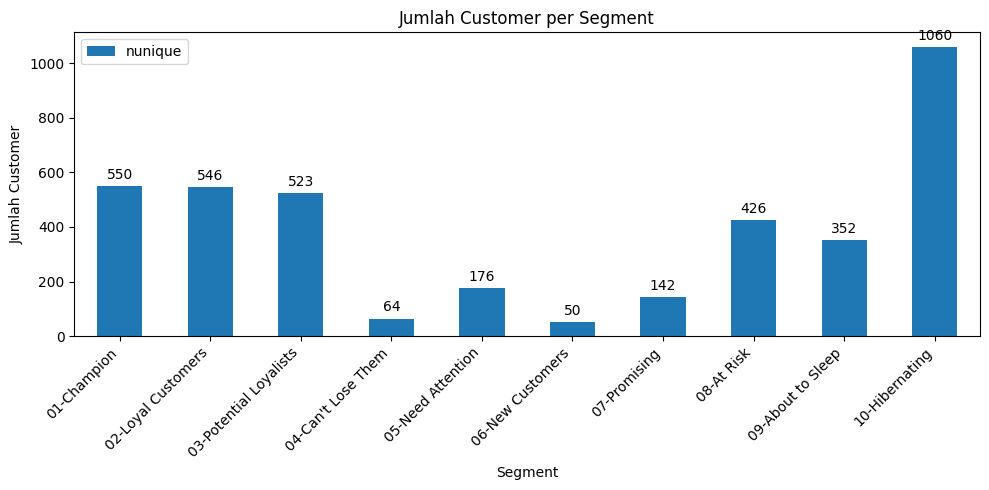

In [16]:
import matplotlib.pyplot as plt

ax = summary['customer_id'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Jumlah Customer per Segment')
plt.xlabel('Segment')
plt.ylabel('Jumlah Customer')
plt.xticks(rotation=45, ha='right')

ax.bar_label(ax.containers[0], fmt='%d', padding=3)

plt.tight_layout()
plt.savefig('images/barchart.png', dpi=150, bbox_inches='tight')
plt.show()

Temuan Utama:


- Churn tinggi pasca pembelian pertama: hanya 20–39% pelanggan kembali di bulan ke-2, mayoritas one-time buyer.
- Kualitas cohort menurun sepanjang paruh pertama tahun: cohort Januari paling loyal (retensi stabil 35–47%), cohort Mei–Juni paling lemah (~20%), lalu sedikit membaik di September–Oktober (~28%).
- Ada efek musiman: retensi naik di bulan November hampir di semua cohort — kemungkinan besar dampak musim belanja akhir tahun.
- Penurunan tajam di Desember kemungkinan bukan sinyal bisnis nyata, melainkan artefak karena data transaksi hanya tersedia sampai 23 Desember (bulan belum lengkap).